### <b><font color='saddlebrown'>EDA датасета Google Play Store</font></b>

##### <b><font color='saddlebrown'>Описание данных</font></b>

- <i>App</i> - название приложения в Google Play Store
- <i>Category</i> - категория приложения
- <i>Rating</i> - средний пользовательский рейтинг приложения по шкале от 1 до 5.
- <i>Reviews</i> - количество пользовательских отзывов о приложении.
- <i>Size</i> - размер приложения
- <i>Installs</i> - количество установок приложения.
- <i>Type</i> - тип приложения: Free (бесплатное) или Paid (платное).
- <i>Price</i> - стоимость приложения в долларах США. Для бесплатных приложений значение равно 0.
- <i>Content Rating</i> - возрастное ограничение контента
- <i>Genres</i> - более детальная жанровая классификация приложения. Может содержать несколько жанров.
- <i>Last Updated</i> - дата последнего обновления приложения в магазине Google Play.
- <i>Current Ver</i> - текущая версия приложения.
- <i>Android Ver</i> - минимальная версия Android, необходимая для установки приложения.

##### <b><font color='saddlebrown'>Задача</font></b>
Провести EDA

In [2]:
# мпорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
googleplaystore = pd.read_csv('../data/googleplaystore.csv')
googleplaystore.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5.6M,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19M,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29M,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33M,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3.1M,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up


In [4]:
googleplaystore.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [5]:
googleplaystore.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [6]:
df_googleplay = googleplaystore.copy() # Создаем копию датафрейма для дальнейшей очистки и анализа
df_googleplay[df_googleplay['Reviews'].str.contains('M', na=False) == True] # Находим строку с некорректным значением в столбце Reviews (строка 10472) и удаляем ее
df_googleplay.drop(10472, inplace = True) # Удаляем строку с некорректным значением в столбце Reviews
df_googleplay['Reviews'] = df_googleplay['Reviews'].str.replace('null', '0').astype(int)   # Заменяем текст 'null' на '0' и преобразуем столбец Reviews в числовой тип данных
df_googleplay.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [7]:
df_googleplay[(df_googleplay['Size'].str.contains('Varies with device', na=False) == True)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,Varies with device,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,Varies with device,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,Varies with device,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,Varies with device,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,Varies with device,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,Varies with device,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,Varies with device,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,Varies with device,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,Varies with device,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [8]:
M = 8829
k = 316
Varies_with_device = 1695
Total = M + k + Varies_with_device
print(Total)
df_googleplay[(df_googleplay['Size'].str.contains('M', na=False) == False) & (df_googleplay['Size'].str.contains('Varies with device', na=False) == False)]

10840


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
58,Restart Navigator,AUTO_AND_VEHICLES,4.0,1403,201k,"100,000+",Free,0,Everyone,Auto & Vehicles,"August 26, 2014",1.0.1,2.2 and up
209,Plugin:AOT v5.0,BUSINESS,3.1,4034,23k,"100,000+",Free,0,Everyone,Business,"September 11, 2015",3.0.1.11 (Build 311),2.2 and up
384,Hangouts Dialer - Call Phones,COMMUNICATION,4.0,122498,79k,"10,000,000+",Free,0,Everyone,Communication,"September 2, 2015",0.1.100944346,4.0.3 and up
450,Caller ID +,COMMUNICATION,4.0,9498,118k,"1,000,000+",Free,0,Everyone,Communication,"June 7, 2016",5.28.0,2.3 and up
458,GO Notifier,COMMUNICATION,4.2,124346,695k,"10,000,000+",Free,0,Everyone,Communication,"July 6, 2014",2.8,2.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10763,FP Разбитый дисплей,FAMILY,4.5,922,552k,"50,000+",Free,0,Everyone,Entertainment,"September 20, 2014",1.1,1.6 and up
10764,FP Transportation,AUTO_AND_VEHICLES,NaN,1,885k,1+,Free,0,Everyone,Auto & Vehicles,"March 9, 2018",10.0.0,4.0 and up
10798,Word Search Tab 1 FR,FAMILY,NaN,0,1020k,50+,Paid,$1.04,Everyone,Puzzle,"February 6, 2012",1.1,3.0 and up
10832,FR Tides,WEATHER,3.8,1195,582k,"100,000+",Free,0,Everyone,Weather,"February 16, 2014",6.0,2.1 and up


In [9]:
df_googleplay['Size'] = df_googleplay['Size'].str.replace('Varies with device', '0k') 
df_googleplay[(df_googleplay['Size'] == '0k')]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
37,Floor Plan Creator,ART_AND_DESIGN,4.1,36639,0k,"5,000,000+",Free,0,Everyone,Art & Design,"July 14, 2018",Varies with device,2.3.3 and up
42,Textgram - write on photos,ART_AND_DESIGN,4.4,295221,0k,"10,000,000+",Free,0,Everyone,Art & Design,"July 30, 2018",Varies with device,Varies with device
52,Used Cars and Trucks for Sale,AUTO_AND_VEHICLES,4.6,17057,0k,"1,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
67,Ulysse Speedometer,AUTO_AND_VEHICLES,4.3,40211,0k,"5,000,000+",Free,0,Everyone,Auto & Vehicles,"July 30, 2018",Varies with device,Varies with device
68,REPUVE,AUTO_AND_VEHICLES,3.9,356,0k,"100,000+",Free,0,Everyone,Auto & Vehicles,"May 25, 2018",Varies with device,Varies with device
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10713,My Earthquake Alerts - US & Worldwide Earthquakes,WEATHER,4.4,3471,0k,"100,000+",Free,0,Everyone,Weather,"July 24, 2018",Varies with device,Varies with device
10725,Posta App,MAPS_AND_NAVIGATION,3.6,8,0k,"1,000+",Free,0,Everyone,Maps & Navigation,"September 27, 2017",Varies with device,4.4 and up
10765,Chat For Strangers - Video Chat,SOCIAL,3.4,622,0k,"100,000+",Free,0,Mature 17+,Social,"May 23, 2018",Varies with device,Varies with device
10826,Frim: get new friends on local chat rooms,SOCIAL,4.0,88486,0k,"5,000,000+",Free,0,Mature 17+,Social,"March 23, 2018",Varies with device,Varies with device


In [10]:
df_googleplay['Size_Measur'] = df_googleplay['Size'].str[-1]
df_googleplay['Size'] = df_googleplay['Size'].str[:-1]
df_googleplay['Size'] = df_googleplay['Size'].astype(float)
df_googleplay

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,M
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,M
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,M
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,0.0,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,k


In [11]:
for index, row in df_googleplay.iterrows():
    if row['Size_Measur'] == 'M':
        df_googleplay.at[index, 'Size'] = row['Size'] * 1024
    elif row['Size_Measur'] == 'k':
        df_googleplay.at[index, 'Size'] = row['Size']
    elif row['Size_Measur'] == '0':
        df_googleplay.at[index, 'Size'] = 0
df_googleplay

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,54272.0,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,M
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3686.4,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,M
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9728.0,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,M
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,0.0,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,k


In [12]:
df_googleplay.head(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5734.4,"50,000+",Free,0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up,M
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19456.0,"50,000+",Free,0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up,M
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29696.0,"1,000,000+",Free,0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up,M
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33792.0,"1,000,000+",Free,0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,M
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3174.4,"10,000+",Free,0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up,M


In [72]:
df_googleplay.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10839 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   App             10839 non-null  object  
 1   Category        10839 non-null  category
 2   Rating          9366 non-null   float64 
 3   Reviews         10839 non-null  int64   
 4   Size            10839 non-null  float64 
 5   Installs        10839 non-null  object  
 6   Type            10839 non-null  category
 7   Price           10839 non-null  float64 
 8   Content Rating  10839 non-null  category
 9   Genres          10839 non-null  category
 10  Last Updated    10839 non-null  object  
 11  Current Ver     10831 non-null  object  
 12  Android Ver     10837 non-null  category
 13  Size_Measur     10839 non-null  object  
dtypes: category(5), float64(3), int64(1), object(5)
memory usage: 907.7+ KB


In [38]:
df_googleplay.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
count,10840,10840,9366.000000,1.084000e+04,10840.000000,10840,10839,10840,10840,10840,10840,10832,10838,10840
unique,9659,33,NaN,NaN,NaN,21,2,92,6,119,1377,2831,33,2
top,ROBLOX,FAMILY,NaN,NaN,NaN,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up,M
freq,9,1972,NaN,NaN,NaN,1579,10039,10040,8714,842,326,1459,2451,8829
mean,NaN,NaN,4.191757,4.441529e+05,18587.426282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.515219,2.927761e+06,22702.948783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,3.800000e+01,2662.400000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,2.094000e+03,9420.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,5.477550e+04,26624.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Size', ylabel='Count'>

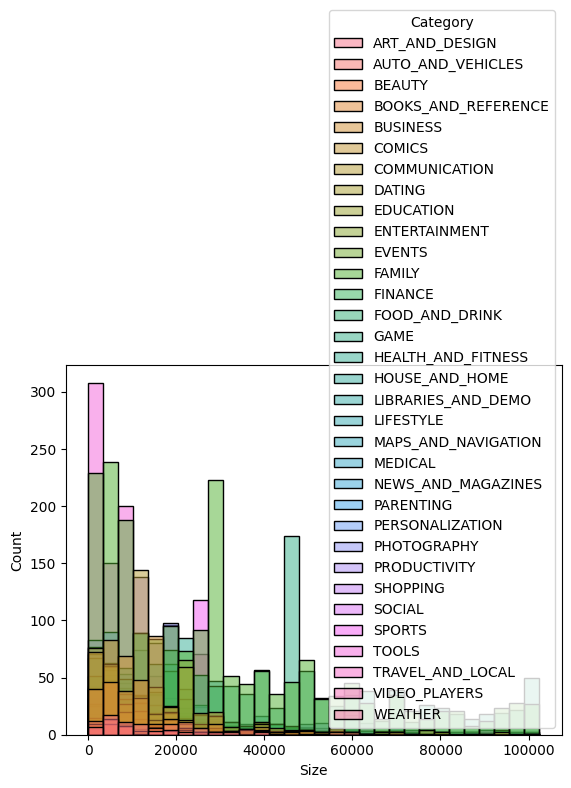

In [52]:
# sns.histplot(df_googleplay['Size'], bins=50, hue='Category')
sns.histplot(data=df_googleplay, x='Size', bins = 30, hue='Category')
# plt.title('Распределение размера приложений')
# plt.xlabel('Размер (кБ)')
# plt.ylabel('Количество приложений')
# plt.show()

In [37]:
cat_cols = ['Genres', 'Android Ver', 'Category', 'Type', 'Content Rating']

for col in cat_cols:
    df_googleplay[col] = df_googleplay[col].astype('category')

In [50]:
df_googleplay.groupby('Category').agg({'Size':'mean'}).sort_values(by='Size', ascending=False)

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\1540736756.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_googleplay.groupby('Category').agg({'Size':'mean'}).sort_values(by='Size', ascending=False)


,Size
Category,
GAME,45434.946601
FAMILY,28998.679803
TRAVEL_AND_LOCAL,25246.169792
SPORTS,24922.953698
HEALTH_AND_FITNESS,23315.303030
PARENTING,23053.274074
FOOD_AND_DRINK,22717.440000
ENTERTAINMENT,22377.813333
EDUCATION,21289.574775


In [49]:
means = (df_googleplay['Size'].replace(0, np.nan).groupby(df_googleplay['Category']).transform('mean'))

df_googleplay['Size'] = df_googleplay['Size'].replace(0, np.nan).fillna(means)

df_googleplay.sort_values(by='Size', ascending=False).head(10)

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\3203795777.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = (df_googleplay['Size'].replace(0, np.nan).groupby(df_googleplay['Category']).transform('mean'))


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
1988,Hungry Shark Evolution,GAME,4.5,6074627,102400.0,"100,000,000+",Free,0,Teen,Arcade,"July 25, 2018",6.0.0,4.1 and up,M
2299,Navi Radiography Pro,MEDICAL,4.7,11,102400.0,500+,Paid,$15.99,Everyone,Medical,"January 14, 2018",1.2.0,4.0.3 and up,M
4690,Vi Trainer,HEALTH_AND_FITNESS,3.6,124,102400.0,"5,000+",Free,0,Everyone,Health & Fitness,"August 2, 2018",2.0.0.11,5.0 and up,M
7404,SimCity BuildIt,FAMILY,4.5,4218587,102400.0,"50,000,000+",Free,0,Everyone 10+,Simulation,"June 19, 2018",1.23.3.75024,4.0 and up,M
5427,Ultimate Tennis,SPORTS,4.3,183004,102400.0,"10,000,000+",Free,0,Everyone,Sports,"July 19, 2018",2.29.3118,4.0.3 and up,M
1565,Talking Babsy Baby: Baby Games,LIFESTYLE,4.0,140995,102400.0,"10,000,000+",Free,0,Everyone,Lifestyle;Pretend Play,"July 16, 2018",9.0,4.0 and up,M
9170,Stickman Legends: Shadow Wars,GAME,4.4,38419,102400.0,"1,000,000+",Paid,$0.99,Everyone 10+,Action,"August 3, 2018",2.3.24,4.1 and up,M
8409,Car Crash III Beam DH Real Damage Simulator 2018,GAME,3.6,151,102400.0,"10,000+",Free,0,Everyone,Racing,"May 20, 2018",1.03,4.1 and up,M
1793,Mini Golf King - Multiplayer Game,GAME,4.5,531458,102400.0,"5,000,000+",Free,0,Everyone,Sports,"July 20, 2018",3.04.1,4.0.3 and up,M
1758,Hungry Shark Evolution,GAME,4.5,6074334,102400.0,"100,000,000+",Free,0,Teen,Arcade,"July 25, 2018",6.0.0,4.1 and up,M


In [55]:
df_googleplay['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [ ]:
df_googleplay['Type'].unique()


['Free', 'Paid', NaN]
Categories (2, object): ['Free', 'Paid']

In [60]:
display(df_googleplay['Type'].isna().sum())
df_googleplay[df_googleplay['Type'].isna() == True]

np.int64(0)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur


In [59]:
df_googleplay.drop(9148, inplace = True)

In [ ]:
df_googleplay['Price']=df_googleplay['Price'].str.replace('$','').astype(float)

AttributeError: Can only use .str accessor with string values!

Text(0.5, 0, 'Тип')

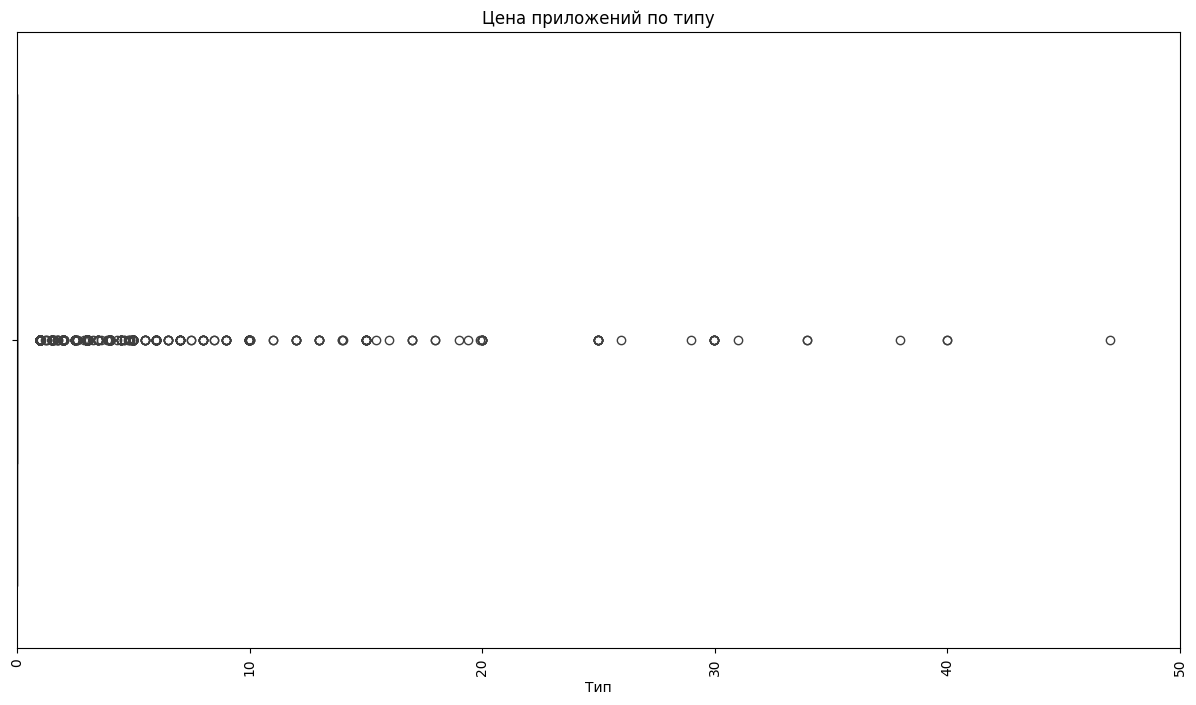

In [77]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Price', data=df_googleplay)
plt.xticks(rotation=90)
plt.xlim(0, 50)
plt.title('Цена приложений по типу')
plt.xlabel('Тип')

In [80]:
df_googleplay[df_googleplay['Price'] > 50]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
2253,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32768.0,"1,000+",Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up,M
2365,Vargo Anesthesia Mega App,MEDICAL,4.6,92,32768.0,"1,000+",Paid,79.99,Everyone,Medical,"June 18, 2018",19.0,4.0.3 and up,M
2390,Language Therapy: Aphasia,MEDICAL,NaN,10,28672.0,"1,000+",Paid,74.99,Everyone,Medical,"June 25, 2018",3.1.1,4.0.3 and up,M
4197,most expensive app (H),FAMILY,4.3,6,1536.0,100+,Paid,399.99,Everyone,Entertainment,"July 16, 2018",1.0,7.0 and up,M
4362,💎 I'm rich,LIFESTYLE,3.8,718,26624.0,"10,000+",Paid,399.99,Everyone,Lifestyle,"March 11, 2018",1.0.0,4.4 and up,M
4367,I'm Rich - Trump Edition,LIFESTYLE,3.6,275,7475.2,"10,000+",Paid,400.00,Everyone,Lifestyle,"May 3, 2018",1.0.1,4.1 and up,M
5351,I am rich,LIFESTYLE,3.8,3547,1843.2,"100,000+",Paid,399.99,Everyone,Lifestyle,"January 12, 2018",2.0,4.0.3 and up,M
5354,I am Rich Plus,FAMILY,4.0,856,8908.8,"10,000+",Paid,399.99,Everyone,Entertainment,"May 19, 2018",3.0,4.4 and up,M
5355,I am rich VIP,LIFESTYLE,3.8,411,2662.4,"10,000+",Paid,299.99,Everyone,Lifestyle,"July 21, 2018",1.1.1,4.3 and up,M
5356,I Am Rich Premium,FINANCE,4.1,1867,4812.8,"50,000+",Paid,399.99,Everyone,Finance,"November 12, 2017",1.6,4.0 and up,M


In [79]:
df_googleplay[df_googleplay['Price']== 0].count()

App               10039
Category          10039
Rating             8719
Reviews           10039
Size              10039
Installs          10039
Type              10039
Price             10039
Content Rating    10039
Genres            10039
Last Updated      10039
Current Ver       10033
Android Ver       10038
Size_Measur       10039
dtype: int64

In [82]:
df_googleplay_free = df_googleplay[df_googleplay['Price'] == 0]
display(df_googleplay_free.head(10))
df_googleplay_paid = df_googleplay[df_googleplay['Price'] > 0]
display(df_googleplay_paid.head(10))

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.0,"10,000+",Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.0,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.8,"5,000,000+",Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.0,"50,000,000+",Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.2,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M
5,Paper flowers instructions,ART_AND_DESIGN,4.4,167,5734.4,"50,000+",Free,0.0,Everyone,Art & Design,"March 26, 2017",1.0,2.3 and up,M
6,Smoke Effect Photo Maker - Smoke Editor,ART_AND_DESIGN,3.8,178,19456.0,"50,000+",Free,0.0,Everyone,Art & Design,"April 26, 2018",1.1,4.0.3 and up,M
7,Infinite Painter,ART_AND_DESIGN,4.1,36815,29696.0,"1,000,000+",Free,0.0,Everyone,Art & Design,"June 14, 2018",6.1.61.1,4.2 and up,M
8,Garden Coloring Book,ART_AND_DESIGN,4.4,13791,33792.0,"1,000,000+",Free,0.0,Everyone,Art & Design,"September 20, 2017",2.9.2,3.0 and up,M
9,Kids Paint Free - Drawing Fun,ART_AND_DESIGN,4.7,121,3174.4,"10,000+",Free,0.0,Everyone,Art & Design;Creativity,"July 3, 2018",2.8,4.0.3 and up,M


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6963.200000,"100,000+",Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up,M
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39936.000000,"100,000+",Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up,M
290,TurboScan: scan documents and receipts in PDF,BUSINESS,4.7,11442,6963.200000,"100,000+",Paid,4.99,Everyone,Business,"March 25, 2018",1.5.2,4.0 and up,M
291,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.8,10295,39936.000000,"100,000+",Paid,4.99,Everyone,Business,"April 11, 2017",3.4.6,3.0 and up,M
427,Puffin Browser Pro,COMMUNICATION,4.0,18247,12048.049057,"100,000+",Paid,3.99,Everyone,Communication,"July 5, 2018",7.5.3.20547,4.1 and up,k
476,"Moco+ - Chat, Meet People",DATING,4.2,1545,17024.567925,"10,000+",Paid,3.99,Mature 17+,Dating,"June 19, 2018",2.6.139,4.1 and up,k
477,Calculator,DATING,2.6,57,6348.800000,"1,000+",Paid,6.99,Everyone,Dating,"October 25, 2017",1.1.6,4.0 and up,M
478,Truth or Dare Pro,DATING,NaN,0,20480.000000,50+,Paid,1.49,Teen,Dating,"September 1, 2017",1.0,4.0 and up,M
479,"Private Dating, Hide App- Blue for PrivacyHider",DATING,NaN,0,18.000000,100+,Paid,2.99,Everyone,Dating,"July 25, 2017",1.0.1,4.0 and up,k
480,Ad Blocker for SayHi,DATING,NaN,4,1228.800000,100+,Paid,3.99,Teen,Dating,"August 2, 2018",1.2,4.0.3 and up,M


Text(0.5, 0, 'Тип')

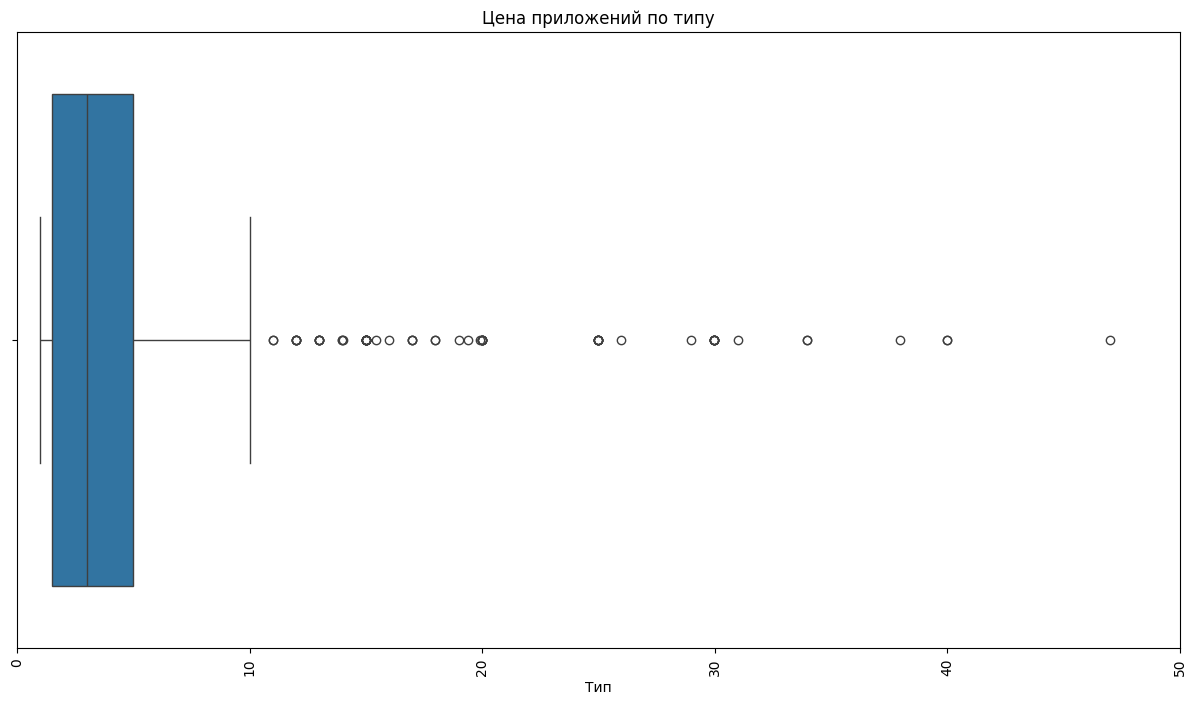

In [83]:
plt.figure(figsize=(15,8))
sns.boxplot(x='Price', data=df_googleplay_paid)
plt.xticks(rotation=90)
plt.xlim(0, 50)
plt.title('Цена приложений по типу')
plt.xlabel('Тип')

In [88]:
display(df_googleplay_free['Content Rating'].groupby(df_googleplay_free['Content Rating']).count())
display(df_googleplay['Content Rating'].groupby(df_googleplay['Content Rating']).count())

Content Rating
Adults only 18+       3
Everyone           8021
Everyone 10+        380
Mature 17+          479
Teen               1156
Name: Content Rating, dtype: int64

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\979779711.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_googleplay['Content Rating'].groupby(df_googleplay['Content Rating']).count())


Content Rating
Adults only 18+       3
Everyone           8714
Everyone 10+        413
Mature 17+          499
Teen               1208
Unrated               2
Name: Content Rating, dtype: int64

In [87]:
df_googleplay_free['Content Rating'] = df_googleplay_free['Content Rating'].str.replace('Unrated', 'Everyone')

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\2547048694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_googleplay_free['Content Rating'] = df_googleplay_free['Content Rating'].str.replace('Unrated', 'Everyone')


In [90]:
display(df_googleplay_free['Genres'].groupby(df_googleplay_free['Genres']).count())
display(df_googleplay_free['Content Rating'].isna().sum())

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\1295330661.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df_googleplay_free['Genres'].groupby(df_googleplay_free['Genres']).count())


Genres
Action                                   341
Action;Action & Adventure                 14
Adventure                                 63
Adventure;Action & Adventure              11
Adventure;Brain Games                      0
                                        ... 
Video Players & Editors                  169
Video Players & Editors;Creativity         2
Video Players & Editors;Music & Video      3
Weather                                   74
Word                                      29
Name: Genres, Length: 119, dtype: int64

np.int64(0)

In [101]:
df_googleplay_free.info()
display(df_googleplay_free)

<class 'pandas.core.frame.DataFrame'>
Index: 10039 entries, 0 to 10840
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   App                10039 non-null  object        
 1   Category           10039 non-null  category      
 2   Rating             8719 non-null   float64       
 3   Reviews            10039 non-null  int64         
 4   Size               10039 non-null  float64       
 5   Installs           10039 non-null  object        
 6   Type               10039 non-null  category      
 7   Price              10039 non-null  float64       
 8   Content Rating     10039 non-null  object        
 9   Genres             10039 non-null  category      
 10  Last Updated       10039 non-null  object        
 11  Current Ver        10033 non-null  object        
 12  Android Ver        10038 non-null  category      
 13  Size_Measur        10039 non-null  object        
 14  Last Update

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur,Last Updated_Date
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19456.000000,"10,000+",Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,M,2018-01-07
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14336.000000,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,M,2018-01-15
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8908.800000,"5,000,000+",Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,M,2018-08-01
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25600.000000,"50,000,000+",Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,M,2018-06-08
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2867.200000,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,M,2018-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,54272.000000,"5,000+",Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,M,2017-07-25
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3686.400000,100+,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,M,2018-07-06
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9728.000000,"1,000+",Free,0.0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up,M,2017-01-20
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,13629.632487,"1,000+",Free,0.0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device,k,2015-01-19


In [ ]:
df_googleplay_free['Last Updated_Date'] = pd.to_datetime(df_googleplay_free['Last Updated'], errors='coerce')


C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\3827731326.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_googleplay_free['Last Updated_Date'] = pd.to_datetime(df_googleplay_free['Last Updated'], errors='coerce')


In [97]:
display(df_googleplay_free['Current Ver'].unique())

array(['1.0.0', '2.0.0', '1.2.4', ..., '0.3.4', '2.96', '2.0.148.0'],
      shape=(2712,), dtype=object)

In [ ]:
display(df_googleplay_free['Current Ver'].isna().sum())
display(df_googleplay_free['Android Ver'].isna().sum())
display(df_googleplay_free['Rating'].isna().sum())

np.int64(6)

np.int64(1)

np.int64(1320)

In [ ]:
df_googleplay_free[df_googleplay_free['Rating'].isna()][['Category', 'Rating', 'App']].groupby('Category').agg({'App':'count'})
# c Rating который ТФТ ничего не делаем они расположены в разных категориях чтобы получилось вывести какой то средний по категории

C:\Users\Vitaliy\AppData\Local\Temp\ipykernel_21176\1269442186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_googleplay_free[df_googleplay_free['Rating'].isna()][['Category', 'Rating', 'App']].groupby('Category').agg({'App':'count'})


,App
Category,
ART_AND_DESIGN,3
AUTO_AND_VEHICLES,10
BEAUTY,11
BOOKS_AND_REFERENCE,33
BUSINESS,154
COMICS,2
COMMUNICATION,54
DATING,36
EDUCATION,1


In [125]:
display(df_googleplay.duplicated().sum())
display(df_googleplay_free.duplicated().sum())

np.int64(483)

np.int64(0)

In [121]:
df_googleplay_free[df_googleplay_free.duplicated() == True].sort_values(by=['App'])

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur,Last Updated_Date
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3891.200000,"500,000+",Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,M,2017-02-17
2543,1800 Contacts - Lens Store,MEDICAL,4.7,23160,26624.000000,"1,000,000+",Free,0.0,Everyone,Medical,"July 27, 2018",7.4.1,5.0 and up,M,2018-07-27
1434,21-Day Meditation Experience,HEALTH_AND_FITNESS,4.4,11506,15360.000000,"100,000+",Free,0.0,Everyone,Health & Fitness,"August 2, 2018",3.0.0,4.1 and up,M,2018-08-02
7035,420 BZ Budeze Delivery,MEDICAL,5.0,2,11264.000000,100+,Free,0.0,Mature 17+,Medical,"June 6, 2018",1.0.1,4.1 and up,M,2018-06-06
1324,8fit Workouts & Meal Planner,HEALTH_AND_FITNESS,4.6,115721,68608.000000,"10,000,000+",Free,0.0,Everyone,Health & Fitness,"July 11, 2018",3.5.0,5.0 and up,M,2018-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3014,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133825,34816.000000,"10,000,000+",Free,0.0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up,M,2018-07-25
3063,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34816.000000,"10,000,000+",Free,0.0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up,M,2018-07-25
3085,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34816.000000,"10,000,000+",Free,0.0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up,M,2018-07-25
3118,trivago: Hotels & Travel,TRAVEL_AND_LOCAL,4.2,219848,25246.169792,"50,000,000+",Free,0.0,Everyone,Travel & Local,"August 2, 2018",Varies with device,Varies with device,k,2018-08-02


In [120]:
df_googleplay_free[df_googleplay_free['App'] == '10 Best Foods for You']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_Measur,Last Updated_Date
1393,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3891.2,"500,000+",Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,M,2017-02-17
1407,10 Best Foods for You,HEALTH_AND_FITNESS,4.0,2490,3891.2,"500,000+",Free,0.0,Everyone 10+,Health & Fitness,"February 17, 2017",1.9,2.3.3 and up,M,2017-02-17


In [124]:
df_googleplay_free = df_googleplay_free.drop_duplicates(keep='first')

In [129]:
df_googleplay_free.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9591 entries, 0 to 10840
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   App                9591 non-null   object        
 1   Category           9591 non-null   category      
 2   Rating             8279 non-null   float64       
 3   Reviews            9591 non-null   int64         
 4   Size               9591 non-null   float64       
 5   Installs           9591 non-null   object        
 6   Type               9591 non-null   category      
 7   Price              9591 non-null   float64       
 8   Content Rating     9591 non-null   object        
 9   Genres             9591 non-null   category      
 10  Current Ver        9585 non-null   object        
 11  Android Ver        9590 non-null   category      
 12  Size_Measur        9591 non-null   object        
 13  Last Updated_Date  9591 non-null   datetime64[ns]
dtypes: category(

In [128]:
del df_googleplay_free['Last Updated']


In [139]:
display(df_googleplay_free['Installs'].groupby(df_googleplay_free['Installs']).count())

Installs
0+                   4
1+                  46
1,000+             751
1,000,000+        1467
1,000,000,000+      49
10+                315
10,000+            915
10,000,000+       1129
100+               616
100,000+          1044
100,000,000+       369
5+                  70
5,000+             404
5,000,000+         683
50+                170
50,000+            433
50,000,000+        272
500+               288
500,000+           505
500,000,000+        61
Name: Installs, dtype: int64

<Axes: xlabel='Rating'>

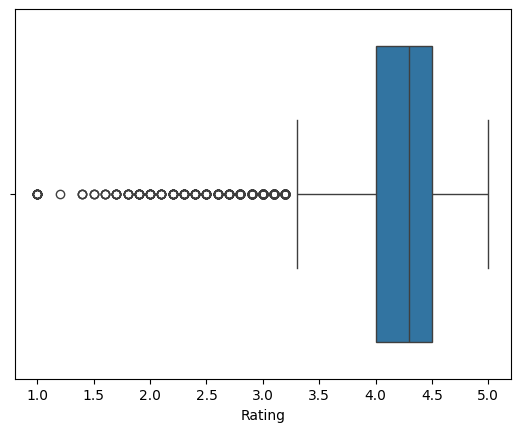

In [130]:
sns.boxplot(x='Rating', data=df_googleplay_free)

<Axes: xlabel='Reviews'>

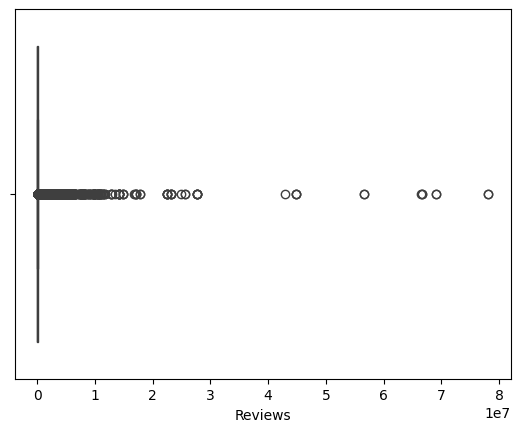

In [131]:
sns.boxplot(x='Reviews', data=df_googleplay_free)

In [137]:
df_googleplay_free[df_googleplay_free['Reviews'] > 10_000_000].sort_values(by='Reviews', ascending=False)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Current Ver,Android Ver,Size_Measur,Last Updated_Date
2544,Facebook,SOCIAL,4.1,78158306,18106.031429,"1,000,000,000+",Free,0.0,Teen,Social,Varies with device,Varies with device,k,2018-08-03
3943,Facebook,SOCIAL,4.1,78128208,18106.031429,"1,000,000,000+",Free,0.0,Teen,Social,Varies with device,Varies with device,k,2018-08-03
336,WhatsApp Messenger,COMMUNICATION,4.4,69119316,12048.049057,"1,000,000,000+",Free,0.0,Everyone,Communication,Varies with device,Varies with device,k,2018-08-03
3904,WhatsApp Messenger,COMMUNICATION,4.4,69109672,12048.049057,"1,000,000,000+",Free,0.0,Everyone,Communication,Varies with device,Varies with device,k,2018-08-03
2604,Instagram,SOCIAL,4.5,66577446,18106.031429,"1,000,000,000+",Free,0.0,Teen,Social,Varies with device,Varies with device,k,2018-07-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050,Minion Rush: Despicable Me Official Game,FAMILY,4.5,10216997,28998.679803,"100,000,000+",Free,0.0,Everyone 10+,Casual;Action & Adventure,Varies with device,Varies with device,k,2018-07-12
1694,Minion Rush: Despicable Me Official Game,GAME,4.5,10216538,45434.946601,"100,000,000+",Free,0.0,Everyone 10+,Casual;Action & Adventure,Varies with device,Varies with device,k,2018-07-12
4036,Minion Rush: Despicable Me Official Game,FAMILY,4.5,10214862,28998.679803,"100,000,000+",Free,0.0,Everyone 10+,Casual;Action & Adventure,Varies with device,Varies with device,k,2018-07-12
1893,Yes day,GAME,4.5,10055521,96256.000000,"100,000,000+",Free,0.0,Everyone,Casual,1_39_93,4.0.3 and up,M,2018-06-28


<Axes: xlabel='Size'>

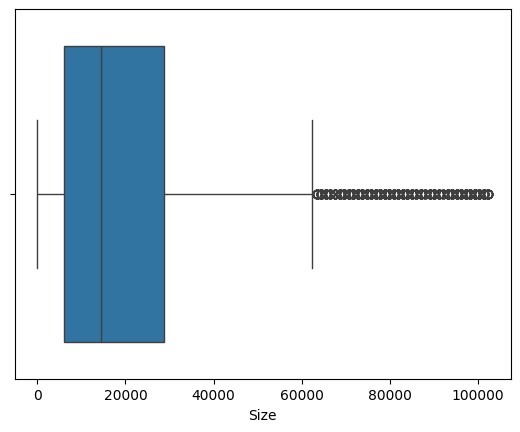

In [138]:
sns.boxplot(x='Size', data=df_googleplay_free)

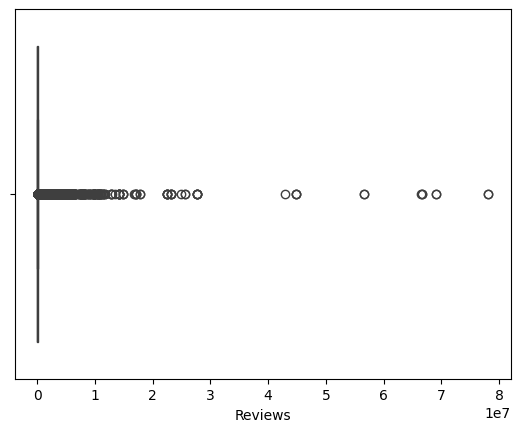

## EDA по чек-листу 1-в-1
Ниже идет новый структурированный блок строго по этапам чек-листа: 1 -> 14.

In [14]:
# 1. Загрузка данных
check_df = pd.read_csv('../data/googleplaystore.csv')
print('Shape:', check_df.shape)
display(check_df.head(3))

Shape: (10841, 13)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up


In [15]:
# 2. Добавление новых столбцов на основе имеющихся
check_df['Reviews_log'] = np.log1p(pd.to_numeric(check_df['Reviews'], errors='coerce'))
check_df['Installs_num'] = pd.to_numeric(check_df['Installs'].astype(str).str.replace(r'[+,]', '', regex=True), errors='coerce')
check_df['Installs_log'] = np.log1p(check_df['Installs_num'])
print(check_df[['Reviews_log', 'Installs_num', 'Installs_log']].head())

   Reviews_log  Installs_num  Installs_log
0     5.075174       10000.0      9.210440
1     6.875232      500000.0     13.122365
2    11.379520     5000000.0     15.424949
3    12.281389    50000000.0     17.727534
4     6.875232      100000.0     11.512935


In [16]:
# 3. Парсинг столбцов
check_df['Rating'] = pd.to_numeric(check_df['Rating'], errors='coerce')
check_df['Reviews'] = pd.to_numeric(check_df['Reviews'], errors='coerce')
check_df['Price'] = pd.to_numeric(check_df['Price'].astype(str).str.replace('$', '', regex=False), errors='coerce')
check_df['Last Updated'] = pd.to_datetime(check_df['Last Updated'], errors='coerce')

# Парсинг размера в MB
size_str_check = check_df['Size'].astype(str).str.strip()
size_num_check = pd.to_numeric(size_str_check.str.replace(r'[^0-9.]', '', regex=True), errors='coerce')
size_unit_check = size_str_check.str.extract(r'([kM])', expand=False)
check_df['Size_MB'] = np.where(size_unit_check == 'k', size_num_check / 1024, size_num_check)
check_df.loc[size_str_check.str.contains('Varies with device', case=False, na=False), 'Size_MB'] = np.nan

print(check_df[['Rating', 'Reviews', 'Price', 'Last Updated', 'Size_MB']].dtypes)

Rating                 float64
Reviews                float64
Price                  float64
Last Updated    datetime64[ns]
Size_MB                float64
dtype: object


In [17]:
# 4. Удаление столбцов
# Удаляем исходный текстовый Installs, потому что уже есть числовой Installs_num.
check_df = check_df.drop(columns=['Installs'])
print('Столбцы после удаления Installs:')
print(check_df.columns.tolist()[:10], '...')

Столбцы после удаления Installs:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated'] ...


In [18]:
# 5. Работа с дубликатами
dup_count = check_df.duplicated().sum()
check_df = check_df.drop_duplicates().copy()
print('Найдено дубликатов:', dup_count)
print('Размер после удаления дубликатов:', check_df.shape)

Найдено дубликатов: 483
Размер после удаления дубликатов: (10358, 16)


In [19]:
# 6. Унификация категорий и единиц измерения
check_df['Type'] = check_df['Type'].astype(str).str.strip().str.title()
check_df['Content Rating'] = check_df['Content Rating'].astype(str).str.strip()
check_df['Category'] = check_df['Category'].astype(str).str.strip().str.upper()
print('Уникальные Type:', check_df['Type'].unique()[:5])

Уникальные Type: ['Free' 'Paid' 'Nan' '0']


In [20]:
# 7. Работа с не типичными значениями (нули, отрицательные, некорректные)
invalid_rating = (~check_df['Rating'].between(1, 5, inclusive='both')).sum()
invalid_price = (check_df['Price'] < 0).sum()
strange_category = check_df['Category'].str.match(r'^\d+(\.\d+)?$', na=False).sum()

check_df = check_df[check_df['Rating'].between(1, 5, inclusive='both')]
check_df = check_df[check_df['Price'].fillna(0) >= 0]
check_df = check_df[~check_df['Category'].str.match(r'^\d+(\.\d+)?$', na=False)]

print('Было аномалий Rating:', invalid_rating)
print('Было отрицательных Price:', invalid_price)
print('Было числовых Category:', strange_category)
print('Размер после чистки нетипичных значений:', check_df.shape)

Было аномалий Rating: 1466
Было отрицательных Price: 0
Было числовых Category: 1
Размер после чистки нетипичных значений: (8892, 16)


In [21]:
# 8. Работа с отсутствующими значениями
check_df['Type'] = check_df['Type'].replace({'Nan': np.nan})
check_df['Content Rating'] = check_df['Content Rating'].replace({'Nan': np.nan})
check_df['Type'] = check_df['Type'].fillna('Unknown')
check_df['Content Rating'] = check_df['Content Rating'].fillna('Unknown')
check_df['Size_MB'] = check_df.groupby('Category', observed=True)['Size_MB'].transform(lambda s: s.fillna(s.median()))

print('Остаток пропусков в ключевых столбцах:')
print(check_df[['Rating', 'Reviews', 'Price', 'Size_MB', 'Type', 'Content Rating']].isna().sum())

Остаток пропусков в ключевых столбцах:
Rating            0
Reviews           0
Price             0
Size_MB           0
Type              0
Content Rating    0
dtype: int64


In [22]:
# 9. Одномерный анализ числовых столбцов
num_cols_check = ['Rating', 'Reviews', 'Installs_num', 'Price', 'Size_MB']
print(check_df[num_cols_check].describe().T)

               count          mean           std       min        25%  \
Rating        8892.0  4.187877e+00  5.223767e-01  1.000000      4.000   
Reviews       8892.0  4.727764e+05  2.905052e+06  1.000000    164.000   
Installs_num  8892.0  1.648965e+07  8.637600e+07  1.000000  10000.000   
Price         8892.0  9.631545e-01  1.618934e+01  0.000000      0.000   
Size_MB       8892.0  2.133142e+01  2.200125e+01  0.008301      5.975   

                   50%         75%           max  
Rating             4.3        4.50  5.000000e+00  
Reviews         4714.5    71266.75  7.815831e+07  
Installs_num  500000.0  5000000.00  1.000000e+09  
Price              0.0        0.00  4.000000e+02  
Size_MB           13.0       29.00  1.000000e+02  


In [23]:
# 10. Одномерный анализ категориальных столбцов
print('Category top-10:')
print(check_df['Category'].value_counts().head(10))
print('\nType:')
print(check_df['Type'].value_counts())
print('\nContent Rating:')
print(check_df['Content Rating'].value_counts())

Category top-10:
Category
FAMILY             1718
GAME               1074
TOOLS               734
PRODUCTIVITY        334
FINANCE             317
PERSONALIZATION     310
COMMUNICATION       307
LIFESTYLE           305
PHOTOGRAPHY         304
MEDICAL             302
Name: count, dtype: int64

Type:
Type
Free    8279
Paid     613
Name: count, dtype: int64

Content Rating:
Content Rating
Everyone           7095
Teen               1022
Mature 17+          411
Everyone 10+        360
Adults only 18+       3
Unrated               1
Name: count, dtype: int64


In [24]:
# 11. Работа с выбросами
q1 = check_df['Reviews_log'].quantile(0.25)
q3 = check_df['Reviews_log'].quantile(0.75)
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
check_df = check_df[check_df['Reviews_log'].between(low, high, inclusive='both')].copy()
print('Размер после фильтра выбросов по Reviews_log:', check_df.shape)

Размер после фильтра выбросов по Reviews_log: (8892, 16)


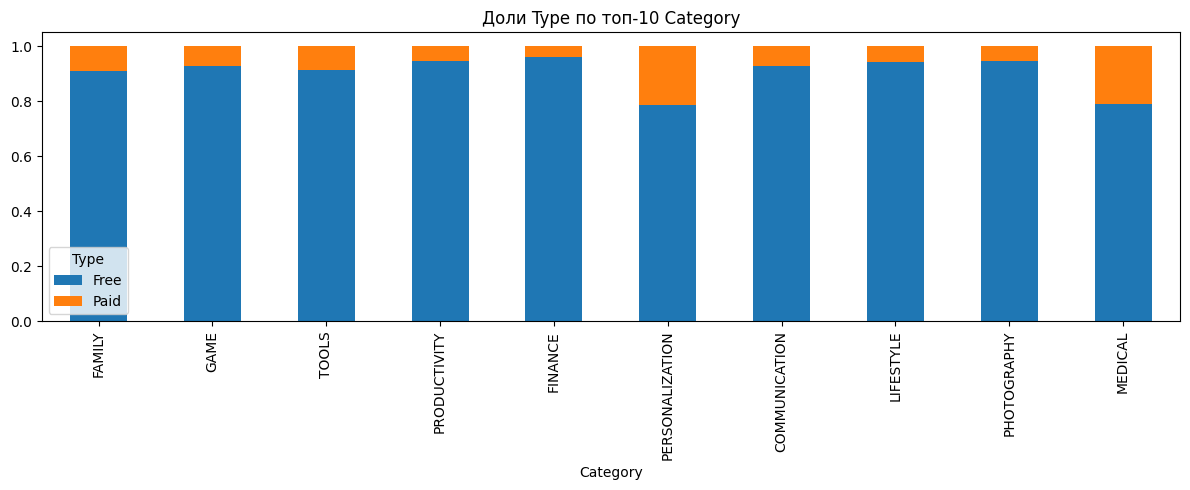

In [25]:
# 12. Двумерный анализ категориальных столбцов
cat2 = pd.crosstab(check_df['Category'], check_df['Type'])
cat2_top = cat2.sum(axis=1).sort_values(ascending=False).head(10).index
cat2_share = cat2.loc[cat2_top].div(cat2.loc[cat2_top].sum(axis=1), axis=0)
cat2_share.plot(kind='bar', stacked=True, figsize=(12, 5))
plt.title('Доли Type по топ-10 Category')
plt.tight_layout()
plt.show()

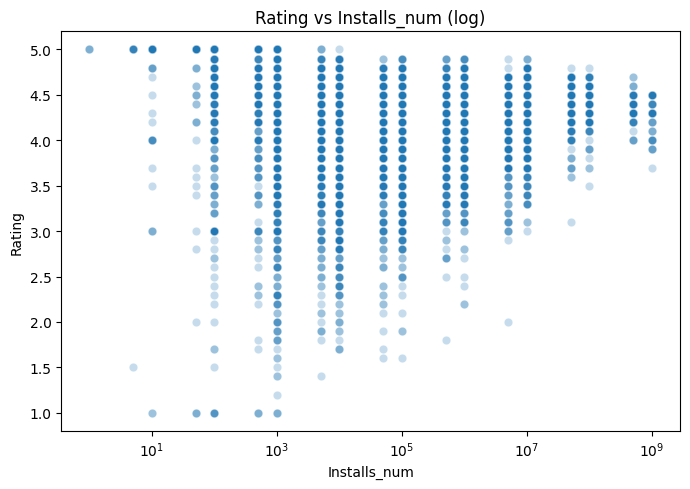

In [26]:
# 13. Двумерный анализ числовых столбцов
plt.figure(figsize=(7, 5))
sns.scatterplot(data=check_df, x='Installs_num', y='Rating', alpha=0.25)
plt.xscale('log')
plt.title('Rating vs Installs_num (log)')
plt.tight_layout()
plt.show()

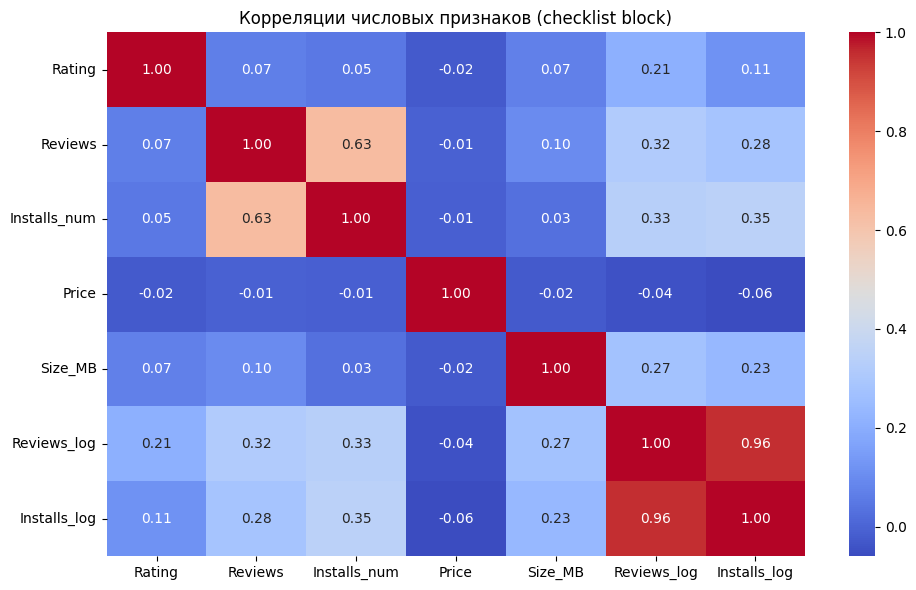

In [27]:
# 14. Многомерный анализ
corr_cols = ['Rating', 'Reviews', 'Installs_num', 'Price', 'Size_MB', 'Reviews_log', 'Installs_log']
plt.figure(figsize=(10, 6))
sns.heatmap(check_df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляции числовых признаков (checklist block)')
plt.tight_layout()
plt.show()